# Exercise 2: Statistical Visualization

This exercise focuses on data visualization using `matplotlib` and `seaborn`. It covers the **M3-2: Statistical Visualization** learning outcomes. We will primarily use the Palmer Penguins dataset. Work through the sections in order.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## A. Fundamentals of plotting

**1.** Explain the difference between a `figure` and an `axes` in `matplotlib`. (1-2 sentences)


1. In Matplotlib, a figure is the overall canvas for a plot, while an axes is the actual plotting area inside the figure where data is drawn (x and y axes).



**2.** Name the three figure-level functions in `seaborn`.


2. In Seaborn, the three figure-level functions are: relplot(), catplot(), and displot().



**3.** Briefly explain the difference between a **Histogram** and a **Barplot**. Which one is used to show the distribution of numerical data, and which is used for categorical data?


3. A histogram shows the distribution of numerical data by grouping values into bins. While barplot displays
aggregated values (like counts or means) for categorical data.
   * Histogram = numerical data
   * Barplot = categorical data


## B. Subplots and Grids

**1.** Using a seaborn **figure-level** function (like `sns.relplot` or `sns.displot`), create subplots using the `col` and `row` parameters. For example, plot `flipper_length_mm` vs `body_mass_g` across columns for `sex` and rows for `island`.

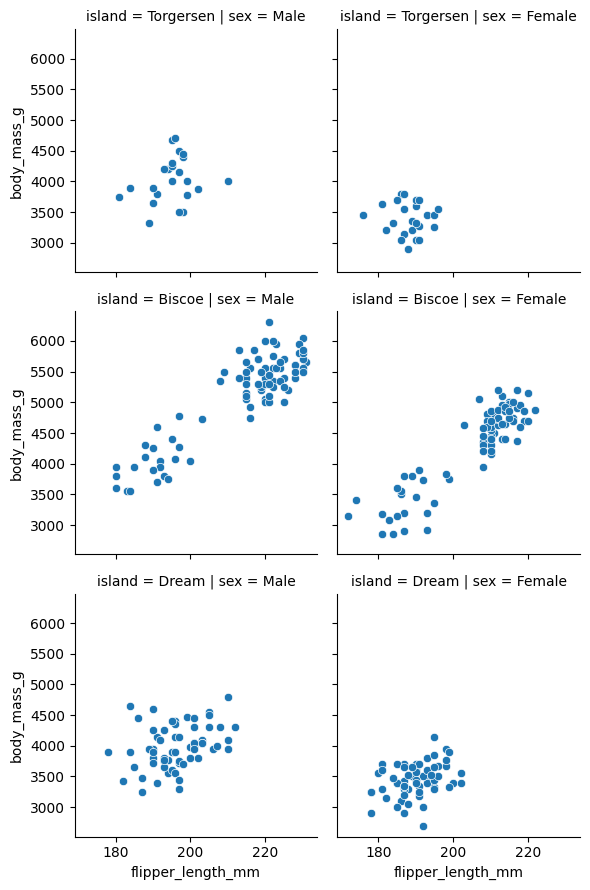

In [2]:
sns.relplot(data = df, x = "flipper_length_mm", y = "body_mass_g", col = "sex", row = "island", height= 3, aspect=1)
plt.show()

**2.** Using **axes-level** functions, create a figure with subplots (e.g., 1 row and 2 columns) using `plt.subplots`.
- Plot a scatterplot of `bill_length_mm` vs `bill_depth_mm` on the first axes (`ax1`).
- Plot a boxplot (or another axes-level plot of your choice) of `bill_length_mm` by `species` on the second axes (`ax2`).
- Make sure to use `sharey=True` (or `sharex=True`) where appropriate so the subplots are linked on the shared dimension.

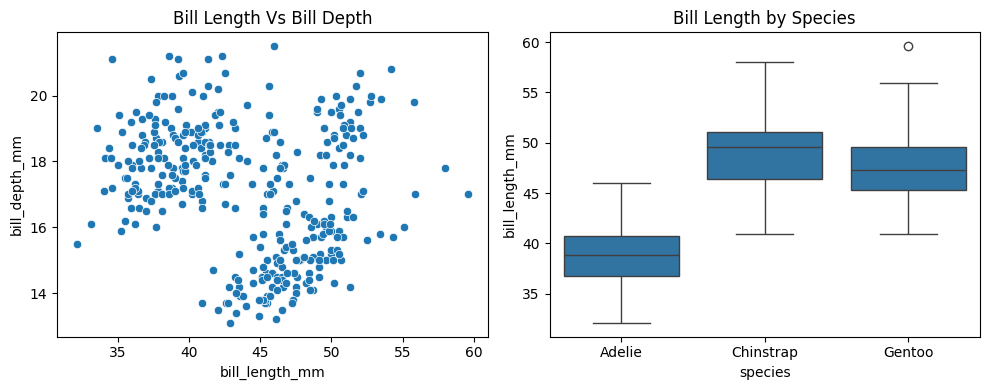

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

# Scatterplot of bill_length_mm Vs bill_depth_mm
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", ax=ax1)
ax1.set_title("Bill Length Vs Bill Depth")

# Boxplot of bill_length_mm by species
sns.boxplot(data=df, x="species", y="bill_length_mm", ax=ax2)
ax2.set_title("Bill Length by Species")

plt.tight_layout()
plt.show()

## C. Visualizing Distributions

**1.** Write code to show a **box plot** of `flipper_length_mm` separated by `species`.

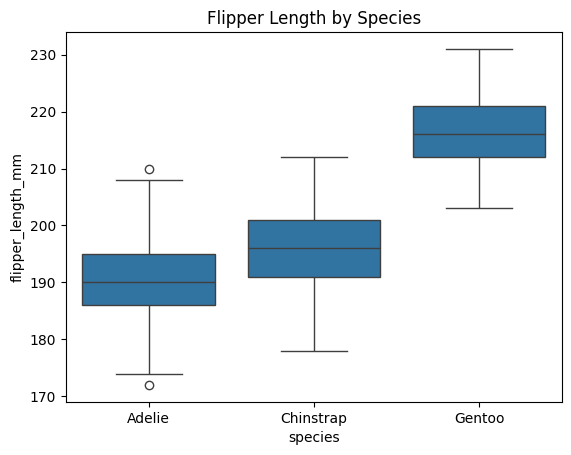

In [4]:
sns.boxplot(data=df, x="species" , y="flipper_length_mm")
plt.title("Flipper Length by Species")
plt.show()



**2.** Show two distributions on the same figure axes: plot the distribution of `body_mass_g` grouped by `sex` (e.g., using `sns.kdeplot`, or `sns.histplot` with overlapping transparent bins).



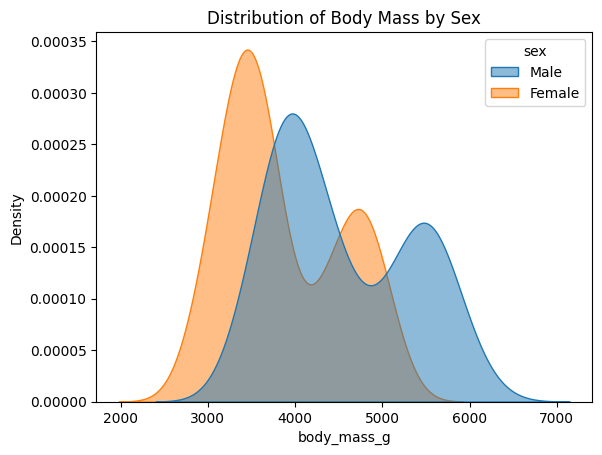

In [5]:
# Kernel Density Estimation (KDE) = draw a smooth curve

sns.kdeplot(data=df, x="body_mass_g", hue="sex", fill=True, alpha=0.5)
plt.title("Distribution of Body Mass by Sex")
plt.show()



**3.** Plot the Empirical Cumulative Distribution Function (**ECDF**) for `body_mass_g`, split by `species`. Briefly interpret what the plot tells you about how the species compare in weight.



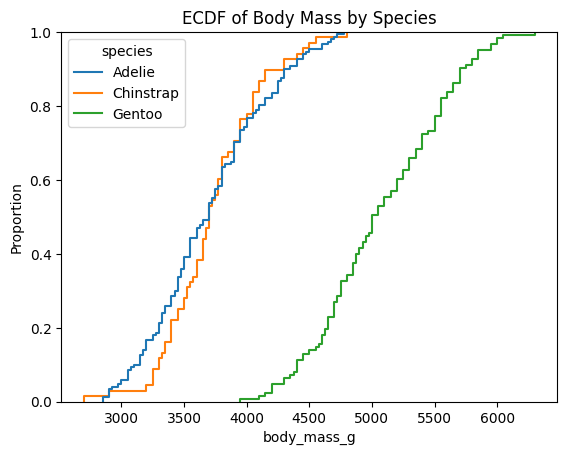

In [6]:
sns.ecdfplot(data=df, x="body_mass_g", hue="species")
plt.title("ECDF of Body Mass by Species")
plt.show()

* From the graph we can see that the Gentoo penguins are the heaviest because their curve is far to the
right, Adelie are the lightest because thier curve is far to the left, and Chinstrap fall in between with a
medium body mass.


**4.** Plot a **bi-variate histogram** using `sns.histplot` showing `bill_length_mm` on the x-axis and `bill_depth_mm` on the y-axis. What does the intensity mapping (the color blocks) represent?



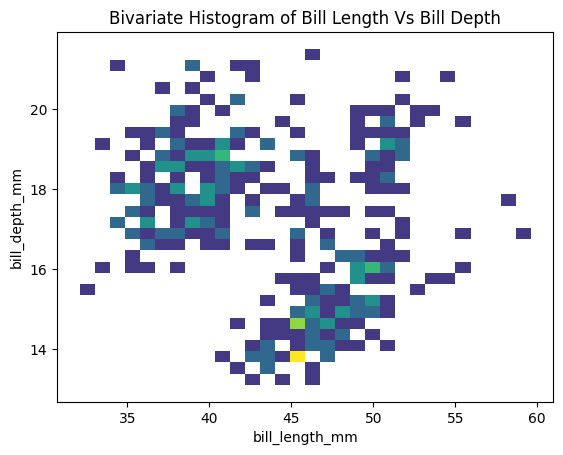

In [7]:
sns.histplot(data=df, x="bill_length_mm", y="bill_depth_mm", bins=30, cmap="viridis")
plt.title("Bivariate Histogram of Bill Length Vs Bill Depth")
plt.show()

The color intensity (color blocks) represents the number of penguins that share similar bill length and depth
measurement in each region.
* Darker color: more penguins in that bin
* Lighter color: fewer penguins
* White or very light: almost no penguins

## D. Categorical Data

**1.** Visualize numerical vs categorical relationships using `sns.catplot()`. Plot `bill_depth_mm` across different `island`s. Experiment with different categorical plot kinds (e.g., `kind='violin'` or `kind='swarm'`).

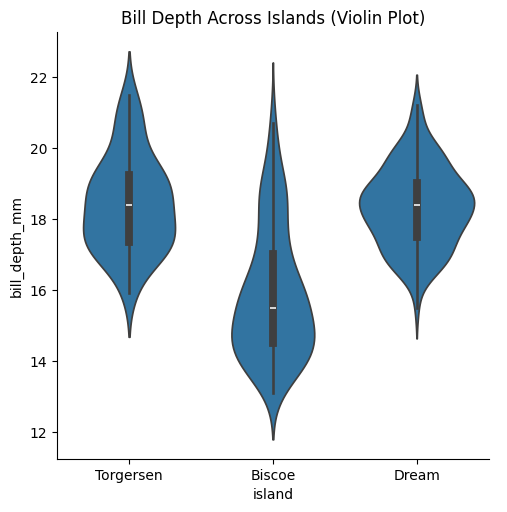

In [8]:
# Violin plot

sns.catplot(data=df, x="island", y="bill_depth_mm", kind="violin")
plt.title("Bill Depth Across Islands (Violin Plot)")
plt.show()

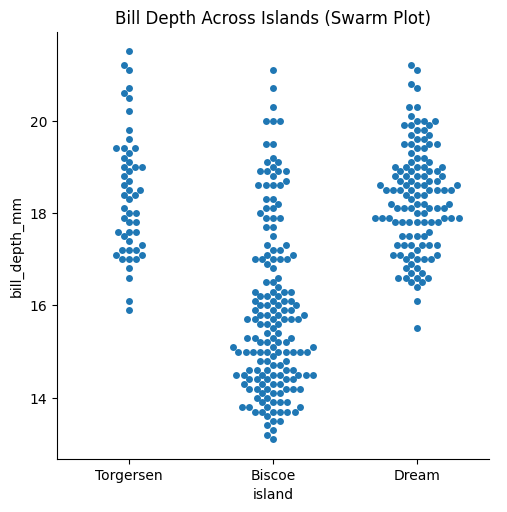

In [9]:
# Swarm Plot

sns.catplot(data=df, x="island", y="bill_depth_mm", kind="swarm")
plt.title("Bill Depth Across Islands (Swarm Plot)")
plt.show()

**2.** Visualize multiple categorical variables in one plot. Show a count of penguins by `island`, and further separate the counts by `species` (using the `hue` parameter in a count plot or a similar approach).

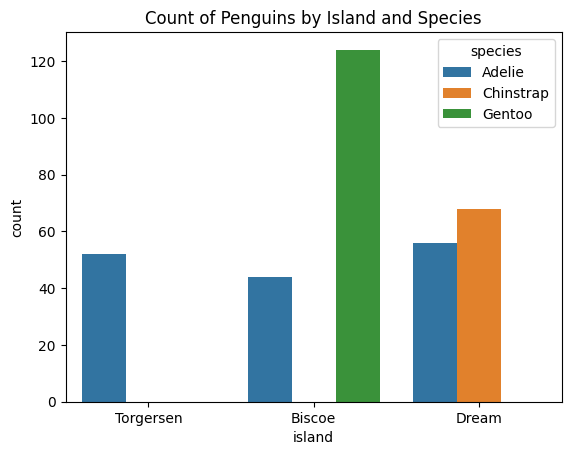

In [10]:
sns.countplot(data=df, x="island", hue="species")
plt.title("Count of Penguins by Island and Species")
plt.show()

## E. Relational Plots and Aesthetics

**1.** Relate two numerical variables using a simple **scatter plot**: plot `bill_length_mm` vs `flipper_length_mm`.

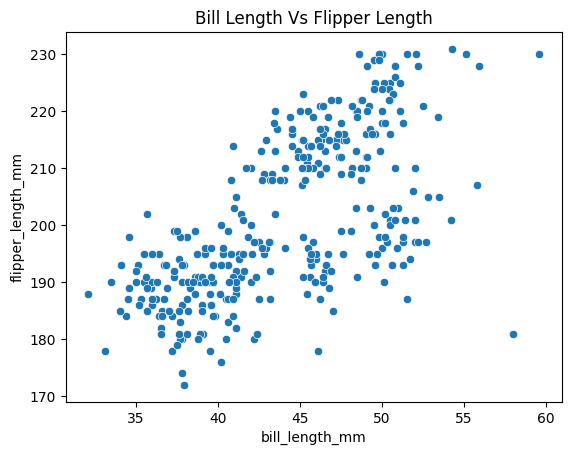

In [11]:
sns.scatterplot(data=df, x="bill_length_mm", y="flipper_length_mm")
plt.title("Bill Length Vs Flipper Length")
plt.show()

**2.** Enhance the scatter plot from the previous step by using different **colors** (`hue`), **markers** (`style`), and **sizes** (`size`) based on other variables in the dataset. Make the plot visually distinct and ensure it is readable.

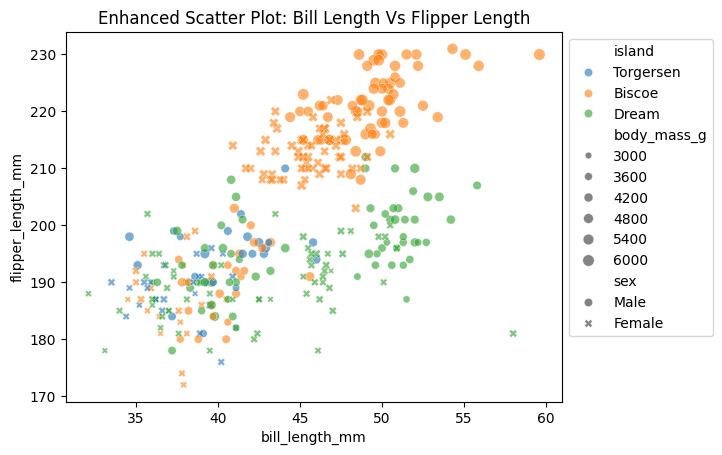

In [12]:
sns.scatterplot(
data=df,
x="bill_length_mm",
y="flipper_length_mm",
hue="island",            # color by island
style="sex",             # different marker shapes for male/female
size="body_mass_g",      # point size reflects body mass
alpha=0.6
)

plt.title("Enhanced Scatter Plot: Bill Length Vs Flipper Length")
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")          # to put the legend outside the plot
plt.show()